In [44]:
using LowLevelFEM

In [45]:
openGeometry("gerber.geo")
#openPreProcessor()

In [46]:

mat1 = Material("ABC")
mat2 = Material("CDE")
U = Field([mat1,mat2], type=:VectorField, dim=2, fieldName=:u, rhsName=:f)
Φ = Field([mat1,mat2], type=:ScalarField, dim=2, fieldName=:φ, rhsName=:m, reducedOrder=true);

In [47]:
t = tangentVector(U, "ABC") + tangentVector(U, "CDE") 
tx, ty, tz = t[1], t[2], t[3]

nx = -ty
ny = tx
nz = 0;

In [48]:
# ------------------------------------------------------------------
# Generalized Timoshenko beam strain
#
# ε = tᵀ ∇u t
# γ = nᵀ ∇u t - φ
# κ = ∇φ ⋅ t
# ------------------------------------------------------------------

Au = [
    tx*tx tx*ty tx*ty ty*ty
    nx*tx nx*ty ny*tx ny*ty
    0 0 0 0]

Aφ = [
    0 0
    0 0
    tx ty]

Gφ = [0; -1; 0;;]

Bu = Au ⋅ Grad(U)

Bφ = Aφ ⋅ Grad(Φ) + Gφ ⋅ Φ;

In [49]:
b = 30
h = 5
E = mat1.E
G = mat1.μ
Iz = b * h^3 / 12
κ = 4 / 5
A = b * h;

In [50]:
D = [
    E*A 0 0
    0 κ*G*A 0
    0 0 E*Iz]

3×3 Matrix{Float64}:
 3.0e7  0.0        0.0
 0.0    9.23077e6  0.0
 0.0    0.0        6.25e7

In [51]:
B = Bu + Bφ
K = ∫(B' ⋅ D ⋅ B, Γ="ABC") + ∫(B' ⋅ D ⋅ B, Γ="CDE");

In [52]:
supp_A = BoundaryCondition("A", field=U, ux=0, uy=0)
supp_B = BoundaryCondition("B", field=U, uy=0)
supp_D = BoundaryCondition("D", field=U, uy=0)

mpc_C = MPC(master="C1", slave="C2", field=U)

MPC("C1", "C2", Problem("gerber", :VectorField, 2, 2, Material[Material("ABC", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0), Material("CDE", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 122, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :u, :f, false), Dict{Symbol, Bool}())

In [53]:
loadf = LoadCondition("AB", fy=-1)
loadF = LoadCondition("E", fy=-100)
loadM = LoadCondition("B", m=0)

fu = loadVector(U, [loadf, loadF])
fφ = loadVector(Φ, [loadM])

F = SystemVector([fu, fφ]);

In [54]:
u, φ = solveField(K, F, support=[supp_A, supp_B, supp_D], mpc=[mpc_C]);

In [55]:
showDoFResults(fu, name="force")
showDoFResults(u, name="u", factor=20, visible=true);

In [56]:
n = VectorField([nx, ny, 0]);

In [57]:
u = expandTo3D(u)
φ = nodesToElements(φ)

g = ∇(u)

ε = t ⋅ (g * t)
γ = n ⋅ (g * t) - φ

κb = ∇(φ) ⋅ t

N = E * A * ε
T = κ * G * A * γ
Mh = E * Iz * κb;

In [58]:
N0, plotN1 = plotOnBeam("ABC", N, name="N graph", plot=true)
T0, plotT1 = plotOnBeam("ABC", T, name="T graph", plot=true)
Mh0, plotMh1 = plotOnBeam("ABC", Mh, name="Mh graph", plot=true)

N1, plotN2 = plotOnBeam("CDE", N, name="N graph", plot=true)
T1, plotT2 = plotOnBeam("CDE", T, name="T graph", plot=true)
Mh1, plotMh2 = plotOnBeam("CDE", Mh, name="Mh graph", plot=true)

(7, ([0.0, 3.333333333333343, 6.666666666666657, 10.0, 10.0, 13.333333333333343, 16.666666666666657, 20.0, 20.0, 23.333333333333343  …  176.66666666666663, 180.0, 180.0, 183.33333333333331, 186.66666666666663, 190.0, 190.0, 193.33333333333331, 196.66666666666663, 200.0], [1.5720931501039814e-9, -333.33333333669344, -666.6666666750538, -1000.0000000134684, -1000.000000007668, -1333.333333337558, -1666.666666667475, -1999.999999997555, -1999.9999999963081, -2333.3333333260357  …  -2333.3333332916936, -1999.9999999599331, -1999.9999999564636, -1666.6666666255978, -1333.3333332950301, -999.9999999641373, -999.9999999687993, -666.6666666467697, -333.33333332463167, -2.168404344971009e-9]))

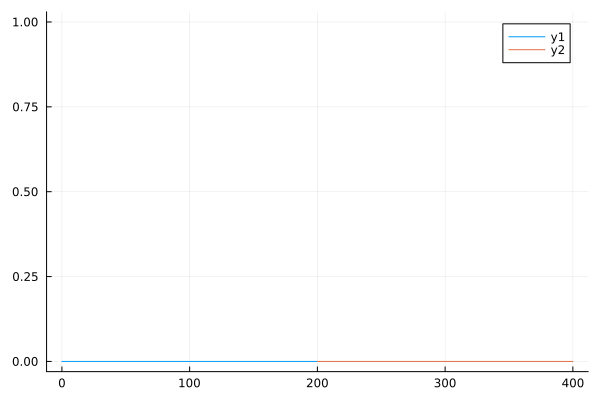

In [64]:
plot(plotN1)
plot!(plotN2[1].+200, plotN2[2])

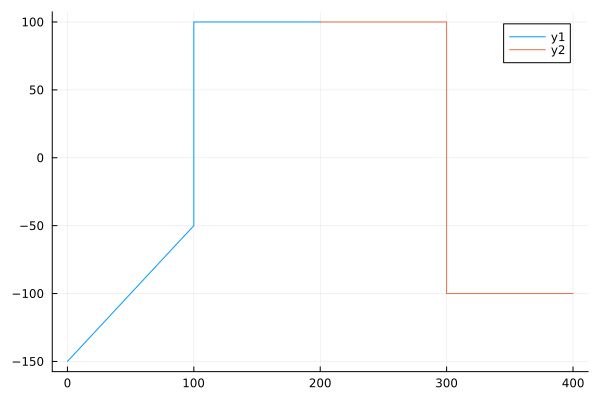

In [ ]:
plot(plotT1)
plot!(plotT2[1].+200, plotT2[2])

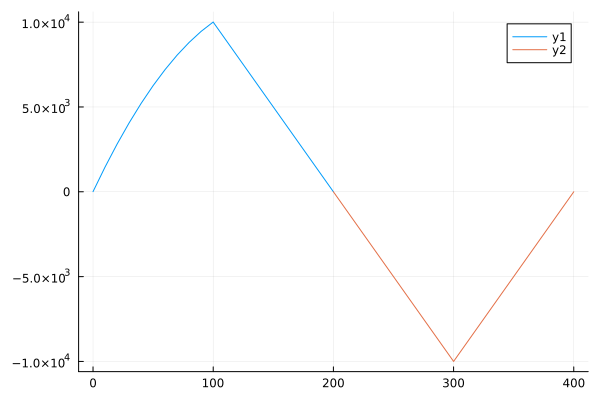

In [62]:
plot(plotMh1)
plot!(plotMh2[1].+200, plotMh2[2])

In [63]:
openPostProcessor()